# Riyadh Grocery Demand Forecasting

**Student:** ZIYAD ABDULLAH ALJOHANI  
**Program:** SDAIA Academy  
**Course:** Time Series Forecasting for AI Systems  
**Program dates:** 20–22 September 2026  
**Submission date:** 21 September 2026  
**Series:** Riyadh / Grocery, daily

The objective is to forecast daily grocery demand and compare several forecasting approaches under the same time-based evaluation. The work starts with the structure of the series, then moves to classical models, LightGBM, walk-forward backtesting, and prediction intervals.

## Overview

The series has a strong weekly cycle, a rising level over time, and several irregular spikes. The main question is not only which model gives the smallest error on one holdout period, but whether that result remains stable when the forecast origin moves through time.

For that reason, the repeated walk-forward results are used as the main comparison. The final 60-day holdout is kept as a separate check rather than being used to choose the model by itself.

## 1. Setup

The notebook runs with the files in this repository. In Colab, the setup cell installs the forecasting packages if they are missing.

In [1]:
import importlib.util, pathlib, subprocess, sys, urllib.request, warnings

REQUIRED = {
    "lightgbm": "lightgbm",
    "prophet": "prophet==1.4.0",
    "sktime": "sktime==1.1.0",
    "cmdstanpy": "cmdstanpy==1.3.0",
    "plotly": "plotly>=5.0",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

ROOT = pathlib.Path.cwd()
(ROOT / "data").mkdir(exist_ok=True)
(ROOT / "common").mkdir(exist_ok=True)
COURSE_RAW = "https://raw.githubusercontent.com/MohammadYusif/time-series-forecasting-ai-systems/main"
for rel in ["data/retail_demand.csv", "common/metrics.py", "common/backtest.py"]:
    dest = ROOT / rel
    if not dest.exists():
        urllib.request.urlretrieve(f"{COURSE_RAW}/{rel}", dest)

sys.path.insert(0, str(ROOT / "common"))
from metrics import mae, rmse, wape, mase, pinball_loss, coverage, interval_width
from backtest import expanding_window_splits, rolling_window_splits, run_backtest, seasonal_naive_forecast

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from lightgbm import LGBMRegressor

RNG_SEED = 20260912
np.random.seed(RNG_SEED)
print("Environment ready. Random seed:", RNG_SEED)

Environment ready. Random seed: 20260912


## 2. Data

I filtered the course data to **Riyadh / Grocery**, sorted it by date, and set it to daily frequency. There are 1,096 observations and no missing days.

In [2]:
df = pd.read_csv("data/retail_demand.csv", parse_dates=["date"])
series = (
    df.query("region == 'Riyadh' and category == 'Grocery'")
      .sort_values("date")
      .set_index("date")["units_sold"]
      .asfreq("D")
)

summary = pd.Series({
    "rows": len(series),
    "start": series.index.min().date(),
    "end": series.index.max().date(),
    "missing_days": int(series.isna().sum()),
    "mean_units": round(series.mean(), 2),
    "std_units": round(series.std(), 2),
    "min_units": series.min(),
    "max_units": series.max(),
})
print(summary)

rows                  1096
start           2023-01-01
end             2025-12-31
missing_days             0
mean_units          669.55
std_units           206.68
min_units            397.0
max_units           2357.0
dtype: object


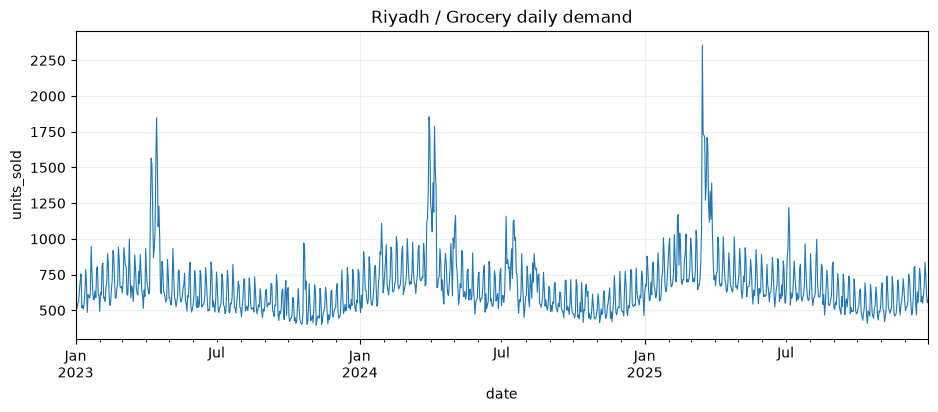

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
series.plot(ax=ax, linewidth=0.8)
ax.set_title("Riyadh / Grocery daily demand")
ax.set_ylabel("units_sold")
ax.grid(alpha=0.2)
plt.show()

## 3. Time-series structure

### STL decomposition

I used a 7-day period because the series has a weekly cycle. Robust STL helps stop a few large spikes from pulling the trend too much.

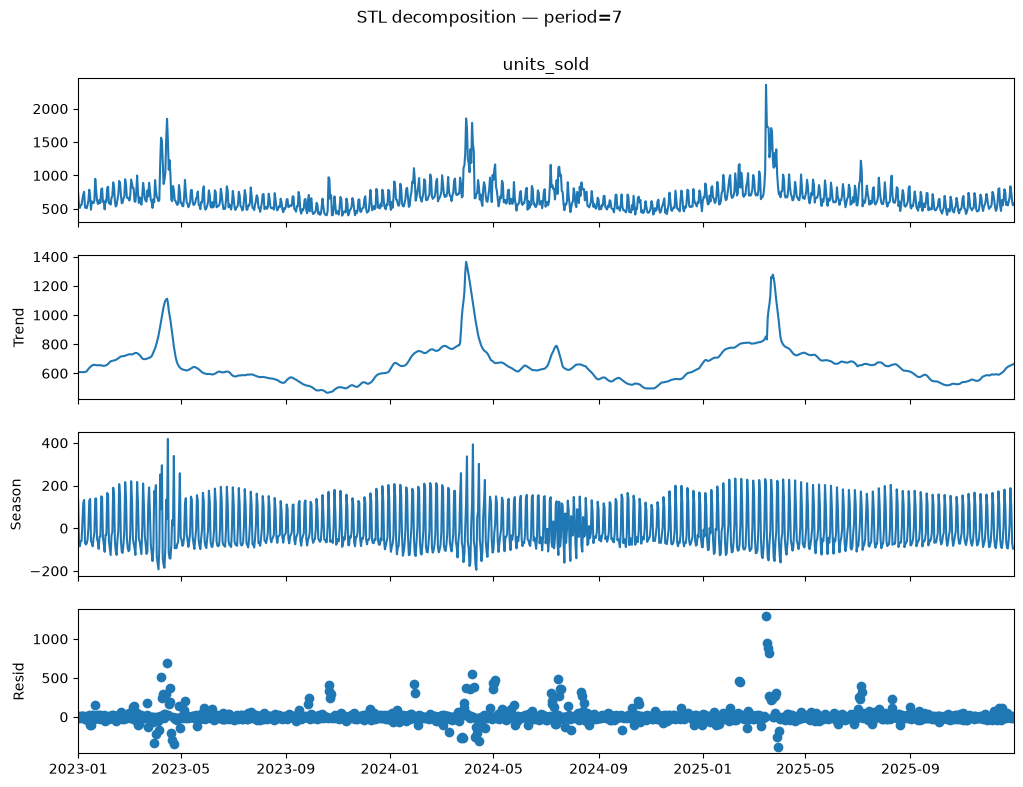

In [4]:
stl = STL(series, period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(11, 8)
fig.suptitle("STL decomposition — period=7", y=1.01)
plt.show()

The trend moves upward through the three years and the weekly pattern is strong. The residuals still contain several large spikes, so the regular seasonal pattern does not explain everything.

### ACF, PACF and stationarity

I checked ACF and PACF on the raw series and after first differencing. The weekly dependence is visible in the lag structure, and the raw series also changes level over time.

I also ran the ADF test. I use it together with the plots rather than using the p-value by itself.

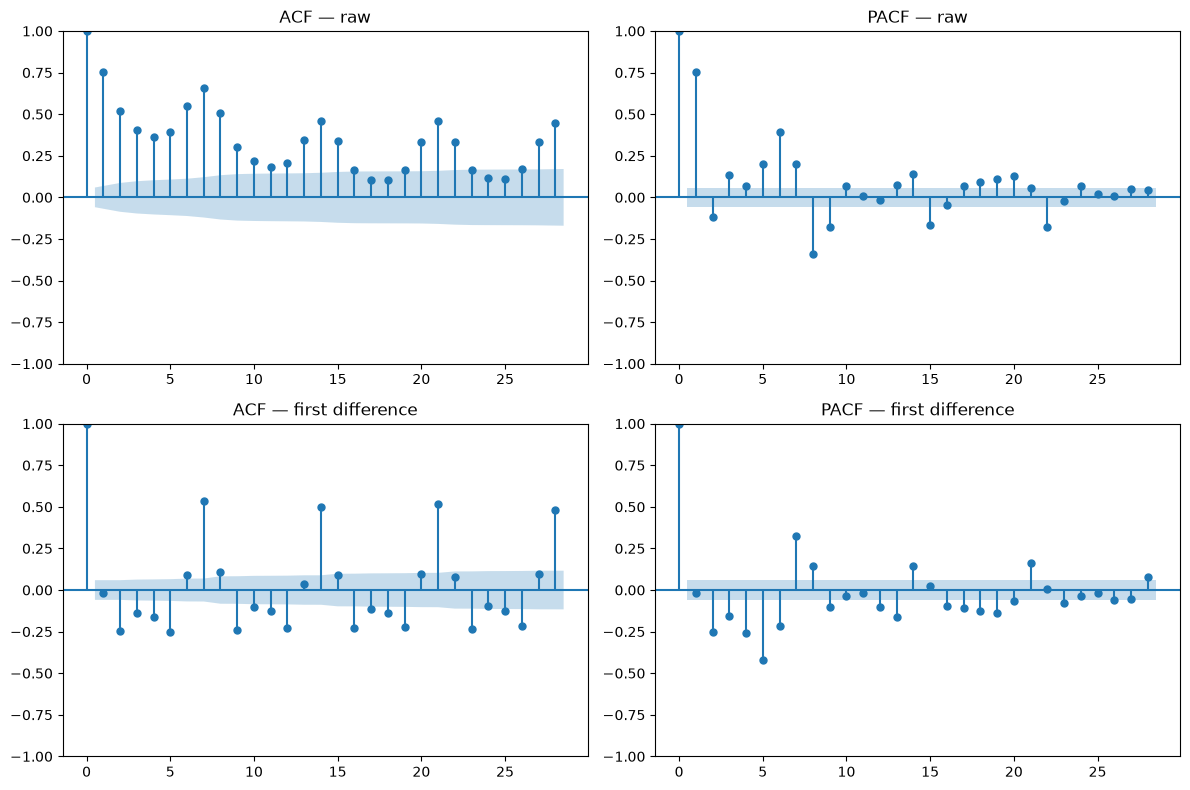

In [5]:
diffed = series.diff().dropna()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(series, lags=28, ax=axes[0, 0])
plot_pacf(series, lags=28, ax=axes[0, 1], method="ywm")
plot_acf(diffed, lags=28, ax=axes[1, 0])
plot_pacf(diffed, lags=28, ax=axes[1, 1], method="ywm")
axes[0, 0].set_title("ACF — raw")
axes[0, 1].set_title("PACF — raw")
axes[1, 0].set_title("ACF — first difference")
axes[1, 1].set_title("PACF — first difference")
plt.tight_layout(); plt.show()

In [6]:
def adf_report(x, label):
    stat, p, usedlag, nobs, crit, icbest = adfuller(x.dropna(), autolag="AIC")
    print(label)
    print(f"  ADF statistic: {stat:.4f}")
    print(f"  p-value: {p:.6g}")
    print("  critical values:", {k: round(v, 4) for k, v in crit.items()})

adf_report(series, "Raw series")
adf_report(diffed, "First difference")

Raw series
  ADF statistic: -3.8721
  p-value: 0.0022504
  critical values: {'1%': np.float64(-3.4365), '5%': np.float64(-2.8642), '10%': np.float64(-2.5682)}
First difference
  ADF statistic: -9.8473
  p-value: 4.58357e-17
  critical values: {'1%': np.float64(-3.4365), '5%': np.float64(-2.8642), '10%': np.float64(-2.5682)}


/tmp/ipykernel_2344/1021853246.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p, usedlag, nobs, crit, icbest = adfuller(x.dropna(), autolag="AIC")
/tmp/ipykernel_2344/1021853246.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p, usedlag, nobs, crit, icbest = adfuller(x.dropna(), autolag="AIC")


The raw ADF p-value is **0.0023**, so the unit-root null is rejected. After first differencing, the p-value drops to **4.58e-17** and the slow ACF decay is reduced.

I kept **d = 1** in the SARIMAX candidate grid because the trend and autocorrelation still make differencing a reasonable modeling choice.

## 4. Classical models

The last 60 days are kept as a holdout. SARIMAX candidates are fitted over a small grid of short AR/MA orders and weekly seasonal terms. Only converged fits are considered, and the final SARIMAX specification is selected from the candidate table using AIC first and BIC as a secondary ordering.

Holt-Winters and a weekly seasonal-naive forecast use the same training period so their holdout errors are directly comparable.

In [7]:
HORIZON = 60
train, test = series.iloc[:-HORIZON], series.iloc[-HORIZON:]

orders = [(0,1,1), (1,1,0), (1,1,1), (1,1,2), (2,1,1)]
seasonal_orders = [(0,1,1,7), (1,1,0,7), (1,1,1,7)]

rows = []
for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConvergenceWarning)
                fit = SARIMAX(
                    train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False, maxiter=300)

            rows.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "converged": bool(fit.mle_retvals.get("converged", False)),
                "aic": fit.aic,
                "bic": fit.bic,
            })
        except Exception:
            continue

sarima_search = (
    pd.DataFrame(rows)
      .query("converged")
      .sort_values(["aic", "bic"])
      .reset_index(drop=True)
)

if sarima_search.empty:
    raise RuntimeError("No SARIMAX candidate converged.")

print(sarima_search.head(10).to_string(index=False))

    order seasonal_order  converged          aic          bic
(1, 1, 2)   (1, 1, 1, 7)       True 12259.867476 12289.421048
(1, 1, 2)   (0, 1, 1, 7)       True 12264.838985 12289.466961
(2, 1, 1)   (1, 1, 1, 7)       True 12270.124682 12299.684144
(2, 1, 1)   (0, 1, 1, 7)       True 12275.329406 12299.962291
(1, 1, 1)   (1, 1, 1, 7)       True 12279.236386 12303.869271
(1, 1, 1)   (0, 1, 1, 7)       True 12283.052666 12302.758974
(0, 1, 1)   (1, 1, 1, 7)       True 12315.811345 12335.517653
(0, 1, 1)   (0, 1, 1, 7)       True 12317.665039 12332.444770
(1, 1, 0)   (1, 1, 1, 7)       True 12337.431916 12357.142148
(1, 1, 0)   (0, 1, 1, 7)       True 12339.566775 12354.349449


In [8]:
best_row = sarima_search.iloc[0]
best_order = tuple(best_row["order"])
best_seasonal_order = tuple(best_row["seasonal_order"])

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    sarimax_fit = SARIMAX(
        train,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=500)

sarimax_converged = bool(sarimax_fit.mle_retvals.get("converged", False))
if not sarimax_converged:
    raise RuntimeError("Selected SARIMAX did not converge.")

sarimax_pred = sarimax_fit.get_forecast(steps=HORIZON).predicted_mean.to_numpy()

hw_fit = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated",
).fit(optimized=True)
hw_pred = hw_fit.forecast(HORIZON).to_numpy()
naive_pred = seasonal_naive_forecast(train.to_numpy(), HORIZON, period=7)

def score_point(y_pred):
    return {
        "MAE": mae(test, y_pred),
        "RMSE": rmse(test, y_pred),
        "WAPE": wape(test, y_pred),
        "MASE": mase(test, y_pred, train, seasonal_period=7),
    }

classical_scores = pd.DataFrame({
    "SARIMAX": score_point(sarimax_pred),
    "Holt-Winters": score_point(hw_pred),
    "Seasonal Naive": score_point(naive_pred),
}).T

print("Selected SARIMAX:", best_order, "x", best_seasonal_order)
print("Converged:", sarimax_converged)
print(classical_scores.round(3))

Selected SARIMAX: (1, 1, 2) x (1, 1, 1, 7)
Converged: True
                    MAE     RMSE    WAPE   MASE
SARIMAX          68.435   83.573  11.586  0.755
Holt-Winters    100.993  113.290  17.099  1.114
Seasonal Naive   78.133   91.609  13.228  0.862


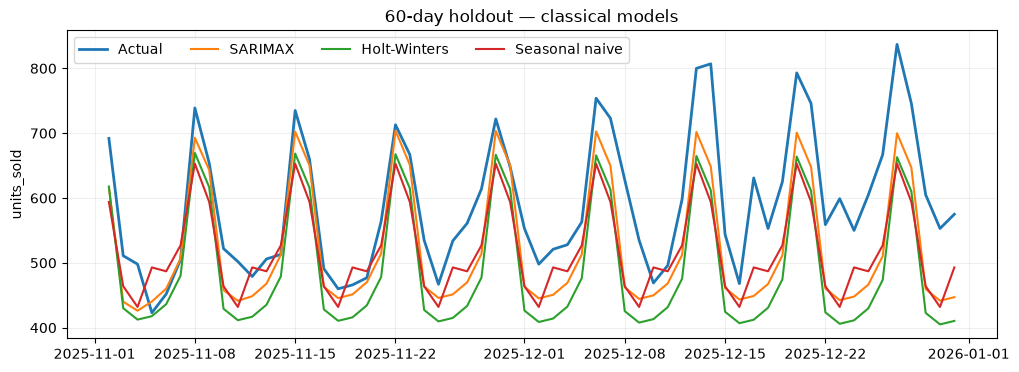

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test.index, test.values, label="Actual", linewidth=2)
ax.plot(test.index, sarimax_pred, label="SARIMAX")
ax.plot(test.index, hw_pred, label="Holt-Winters")
ax.plot(test.index, naive_pred, label="Seasonal naive")
ax.set_title("60-day holdout — classical models")
ax.set_ylabel("units_sold")
ax.legend(ncol=4); ax.grid(alpha=0.2); plt.show()

### Residual check

After fitting SARIMAX, I used the Ljung-Box test at lags 7, 14 and 21 to check whether serial dependence was still left in the residuals.

In [10]:
ljung_box = acorr_ljungbox(sarimax_fit.resid.dropna(), lags=[7, 14, 21], return_df=True)
print(ljung_box.to_string())

      lb_stat  lb_pvalue
7   10.647483   0.154752
14  31.451154   0.004791
21  36.738017   0.018038


At lag 7, the Ljung-Box p-value is **0.155**, so there is no evidence of remaining autocorrelation at that lag. The p-values at lags 14 and 21 are **0.0048** and **0.0180**, so some longer-range structure is still left in the residuals.

This is good enough to keep SARIMAX as a classical benchmark, but not strong enough to claim that the residuals are fully white.

## 5. LightGBM

LightGBM does not know the order of time by itself, so I converted recent history into features: lags 1, 7, 14 and 28, rolling statistics, and calendar fields. Friday and Saturday are marked as the weekend.

The rolling statistics use shifted history, and multi-step forecasts feed each prediction into the next step. Future true values are not used.

In [11]:
def make_features(y):
    y = y.astype(float)
    shifted = y.shift(1)
    X = pd.DataFrame(index=y.index)
    X["lag_1"] = y.shift(1)
    X["lag_7"] = y.shift(7)
    X["lag_14"] = y.shift(14)
    X["lag_28"] = y.shift(28)
    X["roll_mean_7"] = shifted.rolling(7).mean()
    X["roll_mean_28"] = shifted.rolling(28).mean()
    X["roll_std_7"] = shifted.rolling(7).std()
    X["day_of_week"] = X.index.dayofweek
    X["month"] = X.index.month
    X["day_of_year"] = X.index.dayofyear
    X["is_weekend"] = X["day_of_week"].isin([4, 5]).astype(int)  # Friday/Saturday
    return X

FEATURES = ["lag_1","lag_7","lag_14","lag_28","roll_mean_7","roll_mean_28",
            "roll_std_7","day_of_week","month","day_of_year","is_weekend"]

X_train = make_features(train).dropna()
y_train_lgb = train.loc[X_train.index]
lgbm = LGBMRegressor(n_estimators=350, learning_rate=0.035, max_depth=5,
                     num_leaves=24, subsample=0.9, colsample_bytree=0.9,
                     random_state=RNG_SEED, verbosity=-1)
lgbm.fit(X_train[FEATURES], y_train_lgb)
print("Training rows:", len(X_train))
print("Features:", FEATURES)

Training rows: 1008
Features: ['lag_1', 'lag_7', 'lag_14', 'lag_28', 'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'day_of_week', 'month', 'day_of_year', 'is_weekend']


In [12]:
def recursive_forecast(model, history, future_dates):
    history = history.copy().astype(float)
    preds = []
    for date in future_dates:
        working = pd.concat([history, pd.Series([np.nan], index=pd.DatetimeIndex([date]))])
        row = make_features(working).loc[[date], FEATURES]
        pred = float(model.predict(row)[0])
        preds.append(pred)
        # Use each prediction as history for the next step.
        history.loc[date] = pred
    return np.asarray(preds)

lgb_pred = recursive_forecast(lgbm, train, test.index)
lgb_score = score_point(lgb_pred)
for k, v in lgb_score.items():
    print(f"{k}: {v:.3f}")

MAE: 45.586
RMSE: 53.867
WAPE: 7.718
MASE: 0.503


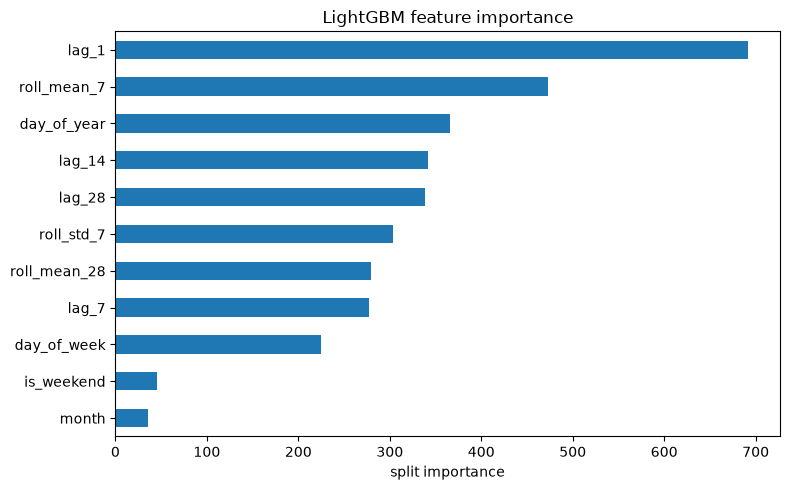

In [13]:
importance = pd.Series(dict(zip(FEATURES, lgbm.feature_importances_))).sort_values()
importance.plot(kind="barh", figsize=(8, 5), title="LightGBM feature importance")
plt.xlabel("split importance"); plt.tight_layout(); plt.show()

**Leakage check:** lag and rolling features only use past values, and every backtest fold is fitted separately.

## 6. Walk-forward backtesting

I used five folds with a 14-day horizon. The expanding version keeps all earlier observations, while the rolling version keeps the most recent 730 days.

Seasonal naive and Holt-Winters are tested in both designs. LightGBM is tested with the expanding folds because those folds start at the beginning of the series, which keeps the calendar dates aligned correctly.

In [14]:
N_FOLDS, BT_HORIZON = 5, 14
expanding_splits = expanding_window_splits(len(series), N_FOLDS, BT_HORIZON, min_train_size=730)
rolling_splits = rolling_window_splits(len(series), N_FOLDS, BT_HORIZON, train_size=730)

# These two models only need y_train, so both split types work.
def naive_fit_predict(y_train, horizon):
    return seasonal_naive_forecast(y_train, horizon, period=7)

def hw_fit_predict(y_train, horizon):
    fit = ExponentialSmoothing(y_train, trend="add", seasonal="add", seasonal_periods=7,
                               initialization_method="estimated").fit(optimized=True)
    return fit.forecast(horizon)

# Expanding folds start at the series origin,
# so dates can be rebuilt from the training length.
SERIES_START = series.index[0]
def lgb_fit_predict(y_train, horizon):
    train_idx = pd.date_range(SERIES_START, periods=len(y_train), freq="D")
    y = pd.Series(y_train, index=train_idx)
    X = make_features(y).dropna(); target = y.loc[X.index]
    model = LGBMRegressor(n_estimators=250, learning_rate=0.04, max_depth=5,
                          num_leaves=24, random_state=RNG_SEED, verbosity=-1)
    model.fit(X[FEATURES], target)
    future_idx = pd.date_range(train_idx[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    return recursive_forecast(model, y, future_idx)

expanding_results = {
    "Seasonal Naive": run_backtest(series.values, expanding_splits, naive_fit_predict),
    "Holt-Winters": run_backtest(series.values, expanding_splits, hw_fit_predict),
    "LightGBM Recursive": run_backtest(series.values, expanding_splits, lgb_fit_predict),
}
rolling_results = {
    "Seasonal Naive": run_backtest(series.values, rolling_splits, naive_fit_predict),
    "Holt-Winters": run_backtest(series.values, rolling_splits, hw_fit_predict),
}
print("Expanding folds:", len(expanding_splits), " Rolling folds:", len(rolling_splits))

Expanding folds: 5  Rolling folds: 5


In [15]:
def fold_table(result_dict):
    rows = []
    for model_name, folds in result_dict.items():
        for r in folds:
            rows.append({
                "model": model_name, "fold": r["fold"],
                "MAE": mae(r["y_true"], r["y_pred"]),
                "RMSE": rmse(r["y_true"], r["y_pred"]),
                "WAPE": wape(r["y_true"], r["y_pred"]),
                "MASE": mase(r["y_true"], r["y_pred"], r["y_train"], seasonal_period=7),
            })
    return pd.DataFrame(rows)

expanding_scores = fold_table(expanding_results)
print(expanding_scores.round(3).to_string(index=False))

             model  fold    MAE   RMSE  WAPE  MASE
    Seasonal Naive     0 36.143 41.595 6.757 0.396
    Seasonal Naive     1 35.714 42.945 6.507 0.394
    Seasonal Naive     2 40.286 48.134 6.985 0.449
    Seasonal Naive     3 58.714 70.185 9.621 0.660
    Seasonal Naive     4 61.214 69.441 9.508 0.690
      Holt-Winters     0 33.996 37.984 6.356 0.373
      Holt-Winters     1 30.342 36.151 5.528 0.335
      Holt-Winters     2 37.869 48.277 6.566 0.422
      Holt-Winters     3 40.525 52.957 6.640 0.455
      Holt-Winters     4 30.728 36.166 4.773 0.347
LightGBM Recursive     0 29.611 33.086 5.536 0.324
LightGBM Recursive     1 28.154 39.115 5.130 0.311
LightGBM Recursive     2 36.985 44.441 6.413 0.412
LightGBM Recursive     3 49.120 59.693 8.049 0.552
LightGBM Recursive     4 41.151 49.673 6.392 0.464


In [16]:
rolling_scores = fold_table(rolling_results)

def summarize(scores):
    return scores.groupby("model")[["WAPE","MASE"]].agg(["mean","std","min","max"])

print("EXPANDING")
print(summarize(expanding_scores).round(3))
print("\nROLLING")
print(summarize(rolling_scores).round(3))

EXPANDING
                     WAPE                        MASE                     
                     mean    std    min    max   mean    std    min    max
model                                                                     
Holt-Winters        5.973  0.803  4.773  6.640  0.386  0.051  0.335  0.455
LightGBM Recursive  6.304  1.122  5.130  8.049  0.413  0.100  0.311  0.552
Seasonal Naive      7.876  1.551  6.507  9.621  0.518  0.146  0.394  0.690

ROLLING
                 WAPE                        MASE                     
                 mean    std    min    max   mean    std    min    max
model                                                                 
Holt-Winters    6.150  1.174  4.351  7.179  0.371  0.062  0.292  0.437
Seasonal Naive  7.876  1.551  6.507  9.621  0.484  0.131  0.372  0.638


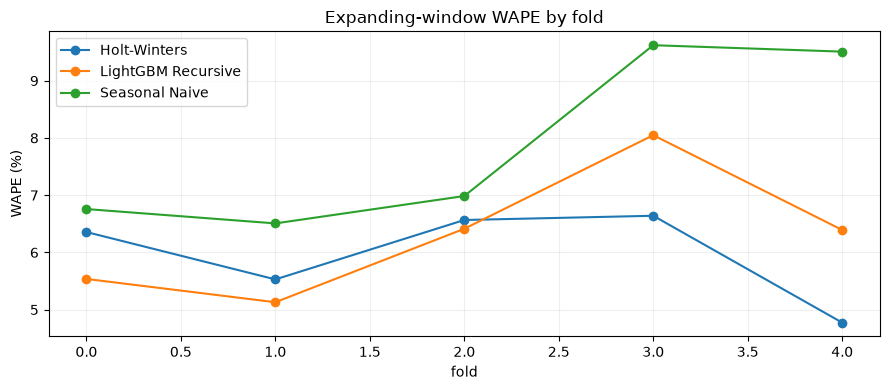

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
for model_name, grp in expanding_scores.groupby("model"):
    ax.plot(grp["fold"], grp["WAPE"], marker="o", label=model_name)
ax.set_title("Expanding-window WAPE by fold")
ax.set_xlabel("fold"); ax.set_ylabel("WAPE (%)")
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

Expanding-window mean WAPE:

- Holt-Winters: **5.97%**
- LightGBM: **6.30%**
- Seasonal naive: **7.88%**

With the 730-day rolling window, Holt-Winters gives **6.15%** and seasonal naive gives **7.88%**.

The final 60-day holdout does not give exactly the same ranking as the repeated folds. SARIMAX reaches **11.59%** WAPE on that holdout, while LightGBM reaches **7.72%**. This difference is why the repeated walk-forward result is used as the main basis for model choice.

## 7. Metrics

MAE and RMSE are reported in units sold. I also use WAPE for a percentage-style error and MASE to compare each forecast with a weekly seasonal-naive scale.

## 8. Prediction intervals

I tested Prophet, quantile LightGBM, sktime Theta, and split conformal prediction.

For the intervals, I look at both coverage and average width. A method can get high coverage simply by producing a very wide interval, so coverage by itself is not enough.

### 8.1 Prophet

In [18]:
from prophet import Prophet

prophet_train = train.rename("y").reset_index().rename(columns={"date": "ds"})[["ds", "y"]]
prophet_model = Prophet(interval_width=0.80)
prophet_model.fit(prophet_train)
future = prophet_model.make_future_dataframe(periods=HORIZON, freq="D")
np.random.seed(RNG_SEED)
prophet_fc = prophet_model.predict(future).tail(HORIZON).reset_index(drop=True)
prophet_yhat = prophet_fc["yhat"].to_numpy()
prophet_lower = prophet_fc["yhat_lower"].to_numpy()
prophet_upper = prophet_fc["yhat_upper"].to_numpy()
prophet_metrics = {
    "MAE": mae(test, prophet_yhat), "WAPE": wape(test, prophet_yhat),
    "coverage": coverage(test, prophet_lower, prophet_upper),
    "width": interval_width(prophet_lower, prophet_upper),
    "pinball@0.5": pinball_loss(test, prophet_yhat, 0.5),
}
print(f"Prophet   MAE={prophet_metrics['MAE']:.1f}  WAPE={prophet_metrics['WAPE']:.1f}%  "
      f"80% coverage={prophet_metrics['coverage']:.1%}  width={prophet_metrics['width']:.1f}  "
      f"pinball@0.5={prophet_metrics['pinball@0.5']:.1f}")

06:15:22 - cmdstanpy - INFO - Chain [1] start processing


06:15:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet   MAE=30.0  WAPE=5.1%  80% coverage=100.0%  width=341.2  pinball@0.5=15.0


### 8.2 Quantile LightGBM

In [19]:
quantile_predictions = {}
for q in (0.1, 0.5, 0.9):
    qm = LGBMRegressor(objective="quantile", alpha=q, n_estimators=350,
                       learning_rate=0.035, max_depth=5, num_leaves=24,
                       random_state=RNG_SEED, verbosity=-1)
    qm.fit(X_train[FEATURES], y_train_lgb)
    quantile_predictions[q] = recursive_forecast(qm, train, test.index)

q10, q50, q90 = quantile_predictions[0.1], quantile_predictions[0.5], quantile_predictions[0.9]
quantile_metrics = {
    "MAE": mae(test, q50), "WAPE": wape(test, q50),
    "coverage": coverage(test, q10, q90), "width": interval_width(q10, q90),
    "pinball_0.1": pinball_loss(test, q10, 0.1),
    "pinball_0.5": pinball_loss(test, q50, 0.5),
    "pinball_0.9": pinball_loss(test, q90, 0.9),
}
print(f"Quantile LightGBM   MAE={quantile_metrics['MAE']:.2f}  WAPE={quantile_metrics['WAPE']:.2f}%  "
      f"80% coverage={quantile_metrics['coverage']:.1%}  width={quantile_metrics['width']:.2f}")
for q, key in [(0.1,'pinball_0.1'),(0.5,'pinball_0.5'),(0.9,'pinball_0.9')]:
    print(f"pinball@{q}={quantile_metrics[key]:.2f}")

Quantile LightGBM   MAE=41.56  WAPE=7.04%  80% coverage=78.3%  width=227.10
pinball@0.1=13.71
pinball@0.5=20.78
pinball@0.9=13.29


### 8.3 sktime interval API

In [20]:
from sktime.forecasting.theta import ThetaForecaster

y_period = series.copy()
y_period.index = pd.PeriodIndex(y_period.index, freq="D")
y_train_sk = y_period.iloc[:-HORIZON]

sk_model = ThetaForecaster(sp=7)
sk_model.fit(y_train_sk)
fh = np.arange(1, HORIZON + 1)
sk_point = sk_model.predict(fh=fh).to_numpy()
sk_interval = sk_model.predict_interval(fh=fh, coverage=0.80)
sk_lower = sk_interval.iloc[:, 0].to_numpy()
sk_upper = sk_interval.iloc[:, 1].to_numpy()
sktime_metrics = {
    "MAE": mae(test, sk_point), "WAPE": wape(test, sk_point),
    "coverage": coverage(test, sk_lower, sk_upper),
    "width": interval_width(sk_lower, sk_upper),
    "pinball@0.5": pinball_loss(test, sk_point, 0.5),
}
print(f"sktime ThetaForecaster   MAE={sktime_metrics['MAE']:.1f}  WAPE={sktime_metrics['WAPE']:.1f}%  "
      f"80% coverage={sktime_metrics['coverage']:.1%}  width={sktime_metrics['width']:.1f}  "
      f"pinball@0.5={sktime_metrics['pinball@0.5']:.1f}")

sktime ThetaForecaster   MAE=72.3  WAPE=12.2%  80% coverage=100.0%  width=1005.9  pinball@0.5=36.2


### 8.4 Split conformal interval

In [21]:
# Split: 946 train, 90 calibration, 60 test.
base_train = series.iloc[:-150]
calibration = series.iloc[-150:-60]
final_test = series.iloc[-60:]

Xb = make_features(base_train).dropna(); yb = base_train.loc[Xb.index]
conf_model = LGBMRegressor(n_estimators=350, learning_rate=0.035, max_depth=5,
                           num_leaves=24, random_state=RNG_SEED, verbosity=-1)
conf_model.fit(Xb[FEATURES], yb)
cal_pred = recursive_forecast(conf_model, base_train, calibration.index)
cal_errors = np.abs(calibration.to_numpy() - cal_pred)

n_cal = len(cal_errors)
q_level = min(1.0, np.ceil((n_cal + 1) * 0.80) / n_cal)
qhat = float(np.quantile(cal_errors, q_level, method="higher"))

# Refit on all observations before the final test.
pretest = series.iloc[:-60]
Xp = make_features(pretest).dropna(); yp = pretest.loc[Xp.index]
conf_final_model = LGBMRegressor(n_estimators=350, learning_rate=0.035, max_depth=5,
                                 num_leaves=24, random_state=RNG_SEED, verbosity=-1)
conf_final_model.fit(Xp[FEATURES], yp)
conf_point = recursive_forecast(conf_final_model, pretest, final_test.index)
conf_lower, conf_upper = conf_point - qhat, conf_point + qhat
print("Calibration points:", n_cal)
print(f"Conformal qhat: {qhat:.2f}")
print(f"Test WAPE: {wape(final_test, conf_point):.2f}%")
print(f"80% nominal coverage: {coverage(final_test, conf_lower, conf_upper):.1%}")
print(f"Mean interval width: {interval_width(conf_lower, conf_upper):.2f}")

Calibration points: 90
Conformal qhat: 69.99
Test WAPE: 8.19%
80% nominal coverage: 78.3%
Mean interval width: 139.99


Quantile LightGBM reaches **78.3% coverage** with mean width **227.10**. Split conformal also reaches **78.3%**, but with a narrower width of **139.99**.

Prophet and sktime Theta both reach **100% coverage**, but their intervals are much wider: **341.2** and **1005.9** respectively. In this run, the wider interval is the trade-off for that extra coverage.

## 9. Model comparison

The models are compared using repeated backtesting, the final holdout, residual diagnostics, and interval quality. These checks answer different questions, so a single error number is not used as the final decision by itself.

| Model | Result | Comment |
|---|---|---|
| Holt-Winters | Expanding mean WAPE **5.97%** | Most consistent point forecast across the repeated folds |
| SARIMAX | Holdout WAPE **11.59%** | Converged; some longer-lag residual autocorrelation remains |
| Prophet | Holdout WAPE **5.1%**, interval width **341.2** | Strong single-holdout point result with a wider interval |
| sktime Theta | Holdout WAPE **12.2%**, interval width **1005.9** | Very conservative interval in this run |
| LightGBM | Expanding mean WAPE **6.30%**, holdout WAPE **7.72%** | Flexible option when additional predictors are available |

### Conclusion

For the current series, **Holt-Winters is the point-forecast benchmark** because it has the lowest average WAPE across the repeated expanding folds and remains close under the rolling-window check.

**LightGBM is the main alternative** if the project later includes promotions, prices, holidays, weather, or other useful predictors. Prophet also performs well on the final holdout and provides native intervals, but that result comes from one holdout rather than the same repeated backtest used for the main point-model comparison.

## 10. Limitations

- The dataset is synthetic, so the results demonstrate the forecasting workflow rather than real retail performance.
- Promotions and holiday effects are not available as future-known inputs.
- Recursive LightGBM can accumulate error across a long forecast horizon.
- SARIMAX still leaves statistically significant residual autocorrelation at longer lags.
- Prophet and sktime are evaluated on the final holdout, not through the same five-fold backtest used for the main point-model comparison.
- Prediction intervals should be recalibrated if the data pattern changes.

## Reproducibility

The repository contains the dataset, shared metric/backtest helpers, package requirements, and an automated execution check. The notebook is executed from top to bottom in Python 3.11 and the run fails if a code cell raises an error.

Random seed: **20260912**.